In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pinxau1000/radioml2018/datasets.desktop
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.json
/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.txt
/kaggle/input/datasets/pinxau1000/radioml2018/LICENSE.TXT
/kaggle/input/datasets/pinxau1000/radioml2018/classes.txt
/kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (4).pt
/kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (13).pt
/kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (10).pt
/kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (7).pt
/kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (19).pt


# 06.1 — Evaluation: Controlled Replication (Phase 1 Only, n_critic=5)

This notebook evaluates the generator from the **controlled replication run**
(`05.1_train_gan.ipynb`) — trained with the paper-specified n_critic=5 and a
doubled data subset (2048 samples per class/SNR cell), for 70 epochs.

**Important scope note:** this checkpoint was trained with **Phase 1 only**
— the cWGAN-GP adversarial loss, with no ambiguity function loss applied.
This is intentional: we are isolating whether `n_critic=5` alone fixes the
mode collapse observed in the original run (`05_train_gan.ipynb`, n_critic=2),
before layering the ambiguity loss back on top in a future Phase 2 run.

**What this notebook measures:**
1. **LPD effectiveness** — can a neural detector tell generated waveforms
   apart from real RF background? (ROC curve, AUC)
2. **Mode collapse check** — using the same diversity metric from the live
   training monitor (`cos_gap`, `std_ratio`), now computed on a much larger
   held-out batch of generated waveforms
3. **Sensing quality** — mainlobe width, peak sidelobe level, integrated
   Doppler ambiguity. We compute these for completeness even though no
   ambiguity loss was applied — we expect these to be unremarkable (neither
   specifically good nor bad), since nothing in Phase 1 training optimises
   for them directly.

**What this notebook does NOT do:** compare directly against the old
collapsed run's numbers (AUC=1.000, ~14× intra-class similarity). That
comparison is deferred until after a Phase 2 ambiguity fine-tune is run on
top of this checkpoint, so the "before vs after" comparison is apples-to-apples
(Phase 2 vs Phase 2), not Phase 1-only vs Phase 2.

## 1. Setup — pull source modules from GitHub

In [2]:
import os, sys

REPO    = "glitching-gops/lpd-radar-waveform"
BRANCH  = "main"
BASE    = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/src"
SRC_DIR = "/kaggle/working/src"
os.makedirs(SRC_DIR, exist_ok=True)

for fname in ["__init__.py", "dataset.py", "models.py", "ambiguity.py"]:
    ret = os.system(f"wget -q -O {SRC_DIR}/{fname} {BASE}/{fname}")
    print(f"  {fname:<15} {'✓' if ret == 0 else '✗ FAILED'}")

sys.path.insert(0, "/kaggle/working")

  __init__.py     ✓
  dataset.py      ✓
  models.py       ✓
  ambiguity.py    ✓


In [3]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from torch.utils.data import TensorDataset, DataLoader, random_split

from src.dataset   import get_loaders, MODULATIONS, SNR_VALUES
from src.models    import Generator, Critic
from src.ambiguity import compute_ambiguity

print("Imports ready ✓")

Imports ready ✓


## 2. Paths and device

Checkpoints from the controlled replication run have gone through several
re-uploads to the Kaggle dataset, so filenames may have `(1)`, `(2)` etc.
suffixes appended automatically by Kaggle. The cell below lists everything
available so you can confirm the correct epoch-70 file before loading it.

In [4]:
# ── device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# ── dataset path ──────────────────────────────────────────────────────────────
HDF5_PATH = None
for dirpath, _, filenames in os.walk("/kaggle/input"):
    for fname in filenames:
        if fname.endswith(".hdf5") or fname.endswith(".h5"):
            HDF5_PATH = os.path.join(dirpath, fname)
assert HDF5_PATH is not None, "HDF5 file not found"
print(f"Dataset : {HDF5_PATH}")

# ── list all checkpoint files available under /kaggle/input ──────────────────
print("\nCheckpoint files found under /kaggle/input:")
found = []
for dirpath, _, filenames in os.walk("/kaggle/input"):
    for fname in filenames:
        if fname.endswith(".pt"):
            full = os.path.join(dirpath, fname)
            size_mb = os.path.getsize(full) / 1e6
            found.append(full)
            print(f"  {full}   ({size_mb:.1f} MB)")

if not found:
    print("  none found — check that your checkpoints dataset is attached")

FIGURES_DIR = "/kaggle/working/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

Device : cuda:0
Dataset : /kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5

Checkpoint files found under /kaggle/input:
  /kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (4).pt   (202.2 MB)
  /kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (13).pt   (202.2 MB)
  /kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (10).pt   (202.2 MB)
  /kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (7).pt   (202.2 MB)
  /kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (19).pt   (202.2 MB)


In [5]:
# ── SET THIS to the exact path printed above for your epoch-70 checkpoint ────
PHASE1_NCRITIC5_CKPT = "/kaggle/input/datasets/venugopalbattula/5-1-checkpoints/latest_ckpt_phase1_ncritic5 (19).pt"

assert os.path.exists(PHASE1_NCRITIC5_CKPT), (
    f"Path not found: {PHASE1_NCRITIC5_CKPT}\n"
    f"Copy the correct path from the listing in the previous cell."
)

# verify epoch number before doing anything else — this is the single most
# important sanity check in this notebook. If this doesn't say epoch 70,
# stop and fix PHASE1_NCRITIC5_CKPT above.
_ckpt_peek = torch.load(PHASE1_NCRITIC5_CKPT, map_location="cpu", weights_only=False)
print(f"Checkpoint epoch : {_ckpt_peek['epoch']}")
print(f"Checkpoint W-dist: {_ckpt_peek['metrics']['w_dist']:.4f}")
del _ckpt_peek

Checkpoint epoch : 70
Checkpoint W-dist: 4.6480


## 3. Load the generator

We load only the generator — the critic is not needed for evaluation.
The generator was trained with `latent_dim=512`, matching the original
architecture (no changes were made to the model itself in the controlled
replication — only the training hyperparameters changed).

In [6]:
G = Generator(latent_dim=512).to(DEVICE)
ckpt = torch.load(PHASE1_NCRITIC5_CKPT, map_location=DEVICE, weights_only=False)
G.load_state_dict(ckpt["G"])
G.eval()

print(f"Generator loaded — epoch {ckpt['epoch']}, "
      f"W-dist at checkpoint: {ckpt['metrics']['w_dist']:.4f}  ✓")

Generator loaded — epoch 70, W-dist at checkpoint: 4.6480  ✓


## 4. Data loaders

We use `samples_per_cell=2048` here — matching the setting used during
this controlled training run. This keeps the conditioning distribution
(the background samples `y` fed to the generator) consistent with what
the generator actually saw during training.

In [7]:
print("Building data loaders (2048 samples/cell, matching training)...")
loader_gen, loader_det, meta = get_loaders(
    HDF5_PATH,
    batch_size=512,
    samples_per_cell=2048,
    cache=True,
)
print(f"Generator loader : {len(loader_gen):,} batches")

N_EVAL = 2048   # number of waveforms to evaluate — same scale as before

Building data loaders (2048 samples/cell, matching training)...
Caching 638,976 samples into RAM...
  50,000 / 638,976
  250,000 / 638,976
  450,000 / 638,976
  638,976 / 638,976
Cached 638,976 samples in 90s  (5.2 GB RAM)
Caching 638,976 samples into RAM...
  50,000 / 638,976
  250,000 / 638,976
  450,000 / 638,976
  638,976 / 638,976
Cached 638,976 samples in 91s  (5.2 GB RAM)
Generator loader : 1,248 batches


## 5. Generate waveforms and build the chirp baseline

generate waveforms conditioned
on real background samples, and build a synthetic chirp baseline for
comparison. Both are normalised to unit standard deviation per sample so
neither the detector nor the sensing metrics can be skewed by amplitude
differences alone.

In [8]:
def normalise(signals: torch.Tensor) -> torch.Tensor:
    """Per-sample, per-channel z-score normalisation. Input: (N, 2, L)"""
    mean = signals.mean(dim=2, keepdim=True)
    std  = signals.std(dim=2,  keepdim=True) + 1e-8
    return (signals - mean) / std


# ── generated waveforms ───────────────────────────────────────────────────────
print("Generating waveforms...")
generated_parts = []
with torch.no_grad():
    for x_batch, _, _ in loader_gen:
        if sum(p.size(0) for p in generated_parts) >= N_EVAL:
            break
        z     = torch.randn(x_batch.size(0), 512, 1, device=DEVICE)
        x_gen = G(z, x_batch.to(DEVICE))
        generated_parts.append(x_gen.cpu())

generated = normalise(torch.cat(generated_parts, dim=0)[:N_EVAL])
print(f"Generated shape : {generated.shape}  std={generated.std():.4f}")


# ── chirp baseline ────────────────────────────────────────────────────────────
def make_chirp_batch(n: int, N: int = 1024, bandwidth: float = 5.0) -> torch.Tensor:
    t     = torch.linspace(0, 1, N)
    phase = 2 * torch.pi * bandwidth * t ** 2 / 2
    sig   = torch.stack([torch.cos(phase), torch.sin(phase)], dim=0)
    return sig.unsqueeze(0).expand(n, -1, -1).clone()

chirps = normalise(make_chirp_batch(N_EVAL))
print(f"Chirp shape     : {chirps.shape}  std={chirps.std():.4f}")


# ── background pool (negative class for detector) ─────────────────────────────
print("Collecting background samples...")
bg_parts = []
for x_bg, _, _ in loader_gen:
    bg_parts.append(x_bg)
    if sum(p.size(0) for p in bg_parts) >= 4 * N_EVAL:
        break

bg_pool = torch.cat(bg_parts, dim=0)
perm    = torch.randperm(bg_pool.size(0))
bg_pool = bg_pool[perm]
print(f"Background pool : {bg_pool.shape}  std={bg_pool.std():.4f}")

Generating waveforms...
Generated shape : torch.Size([2048, 2, 1024])  std=0.9995
Chirp shape     : torch.Size([2048, 2, 1024])  std=0.9995
Background pool : torch.Size([8192, 2, 1024])  std=1.0000


## 6. Mode collapse check — same metric as the live training monitor

During training we watched `cos_gap` (generated intra-class cosine
similarity minus background intra-class cosine similarity) and `std_ratio`
(background std ÷ generated std) every epoch. Both stayed flat and healthy
for the last ~50 epochs of training on a small fixed 256-sample monitoring
batch.

Here we recompute the same two metrics on the full 2048-sample evaluation
batch — a much larger sample than the training monitor used, giving us a
more statistically reliable readout of whether the generator is actually
diverse or just appeared diverse on a lucky small sample.

In [9]:
def diversity_check(gen: torch.Tensor, bg: torch.Tensor) -> dict:
    """Same cos_gap / std_ratio metric used during training, on a larger batch."""
    gen_std = gen.std(dim=0).mean().item()
    bg_std  = bg.std(dim=0).mean().item()

    gf  = gen.flatten(1)
    gf  = gf / (gf.norm(dim=1, keepdim=True) + 1e-8)
    cos = gf @ gf.T
    n   = cos.size(0)
    gen_cos = (cos.sum() - cos.diag().sum()).item() / (n * (n - 1))

    bf   = bg.flatten(1)
    bf   = bf / (bf.norm(dim=1, keepdim=True) + 1e-8)
    cosb = bf @ bf.T
    nb   = cosb.size(0)
    bg_cos = (cosb.sum() - cosb.diag().sum()).item() / (nb * (nb - 1))

    return {
        "gen_std": gen_std, "bg_std": bg_std,
        "std_ratio": bg_std / (gen_std + 1e-8),
        "gen_cos": gen_cos, "bg_cos": bg_cos,
        "cos_gap": gen_cos - bg_cos,
    }


div = diversity_check(generated, bg_pool[:N_EVAL])

print("Diversity check — full 2048-sample evaluation batch:")
print(f"  std_ratio : {div['std_ratio']:.4f}   (1.0 = healthy, training showed ~1.008)")
print(f"  cos_gap   : {div['cos_gap']:+.4f}   (0.0 = healthy, training showed ~0.014)")
print(f"  gen_cos   : {div['gen_cos']:+.4f}   (generated intra-class similarity)")
print(f"  bg_cos    : {div['bg_cos']:+.4f}   (background intra-class similarity, reference)")

print(f"\nFor reference, the OLD collapsed run (n_critic=2) showed roughly")
print(f"14× higher intra-class similarity than background at evaluation time.")
if div["gen_cos"] > 0 and div["bg_cos"] != 0:
    print(f"This run's ratio (gen_cos / |bg_cos|): "
          f"{abs(div['gen_cos'] / (abs(div['bg_cos']) + 1e-8)):.1f}×  "
          f"(interpret cautiously — bg_cos is near zero, so this ratio is unstable;"
          f" cos_gap above is the more reliable number)")

Diversity check — full 2048-sample evaluation batch:
  std_ratio : 1.0053   (1.0 = healthy, training showed ~1.008)
  cos_gap   : +0.0094   (0.0 = healthy, training showed ~0.014)
  gen_cos   : +0.0094   (generated intra-class similarity)
  bg_cos    : +0.0000   (background intra-class similarity, reference)

For reference, the OLD collapsed run (n_critic=2) showed roughly
14× higher intra-class similarity than background at evaluation time.
This run's ratio (gen_cos / |bg_cos|): 401682.5×  (interpret cautiously — bg_cos is near zero, so this ratio is unstable; cos_gap above is the more reliable number)


## 7. Visual inspection

Plot a handful of generated waveforms alongside chirp baseline samples.
If mode collapse were present, generated samples would look visually
near-identical to each other. Given the healthy `cos_gap` above, we expect
to see visibly different waveforms here.

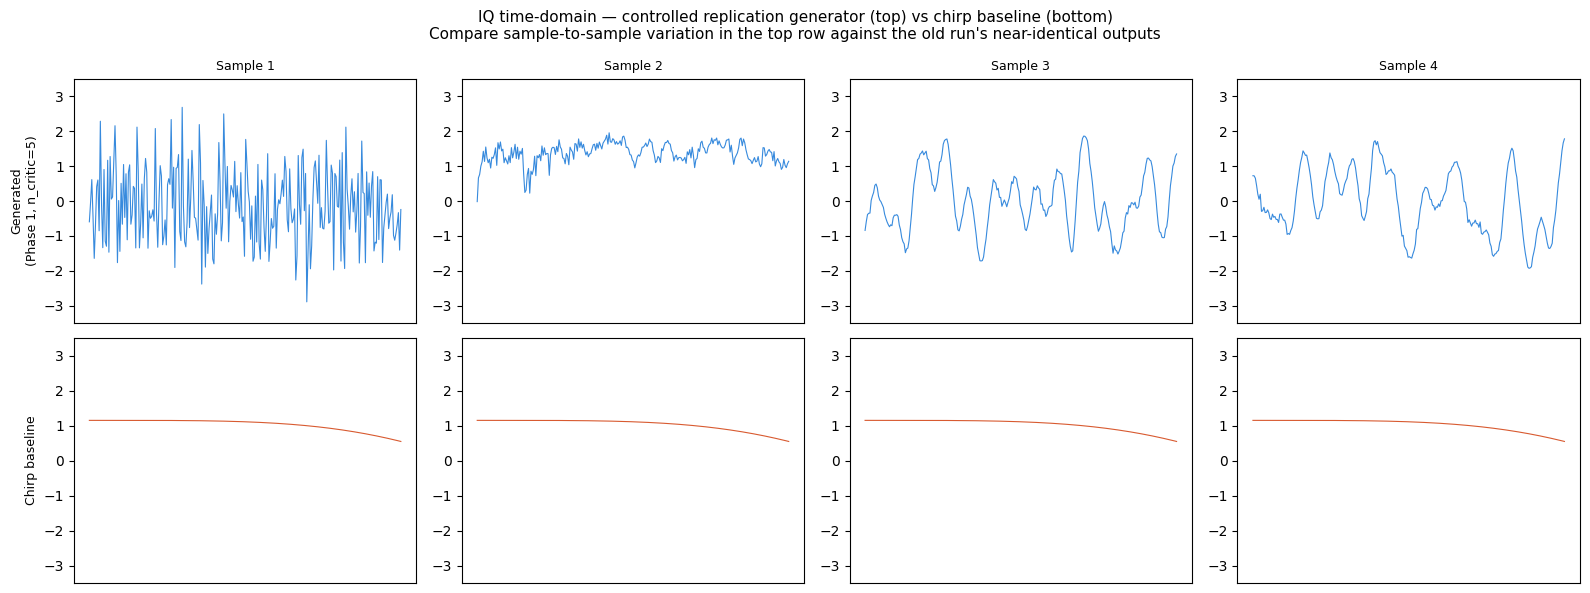

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for col in range(4):
    ax = axes[0, col]
    ax.plot(generated[col, 0, :256].numpy(), linewidth=0.8, color="#378ADD")
    ax.set_ylim(-3.5, 3.5)
    ax.set_xticks([])
    if col == 0:
        ax.set_ylabel("Generated\n(Phase 1, n_critic=5)", fontsize=9)
    ax.set_title(f"Sample {col+1}", fontsize=9)

    ax = axes[1, col]
    ax.plot(chirps[col, 0, :256].numpy(), linewidth=0.8, color="#D85A30")
    ax.set_ylim(-3.5, 3.5)
    ax.set_xticks([])
    if col == 0:
        ax.set_ylabel("Chirp baseline", fontsize=9)

fig.suptitle(
    "IQ time-domain — controlled replication generator (top) vs chirp baseline (bottom)\n"
    "Compare sample-to-sample variation in the top row against the old run's near-identical outputs",
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eval061_01_waveform_samples.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 8. LPD effectiveness — ResNet-18 detector

Same detector architecture and training protocol as the original
evaluation notebook. The detector is trained from scratch here — a fresh
network, so its performance reflects only what the current generator's
outputs make possible, not any leftover bias from a previously trained
detector.

**Dataset construction** (same fix as the original 06 notebook):
- Positive class (label=1): generated + chirp waveforms, unit-std normalised
- Negative class (label=0): background samples from the same pool, unit-std normalised
- No signal mixing — the detector must find structural differences, not
  power-level differences

In [11]:
class ResNet18_1D(nn.Module):
    """1D ResNet-18 binary detector. Input: (B, 2, 1024) → Output: (B, 1)"""

    def __init__(self):
        super().__init__()

        def block(in_ch, out_ch, stride=1):
            main = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
                nn.Conv1d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm1d(out_ch),
            )
            skip = nn.Sequential()
            if stride != 1 or in_ch != out_ch:
                skip = nn.Sequential(
                    nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                    nn.BatchNorm1d(out_ch),
                )
            return nn.ModuleList([main, skip])

        self.stem = nn.Sequential(
            nn.Conv1d(2, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(3, stride=2, padding=1),
        )
        self.blocks = nn.ModuleList([
            block(64,  64),
            block(64,  128, stride=2),
            block(128, 256, stride=2),
            block(256, 512, stride=2),
        ])
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(512, 1),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.stem(x)
        for main, skip in self.blocks:
            x = self.relu(main(x) + skip(x))
        return self.head(x)

In [12]:
# ── build detector dataset ────────────────────────────────────────────────────
pos_signals = torch.cat([generated, chirps], dim=0)
neg_signals = bg_pool[N_EVAL : N_EVAL + 2 * N_EVAL]

pos_labels = torch.ones(pos_signals.size(0), 1)
neg_labels = torch.zeros(neg_signals.size(0), 1)

X_det = torch.cat([pos_signals, neg_signals], dim=0)
y_det = torch.cat([pos_labels,  neg_labels],  dim=0)

perm  = torch.randperm(X_det.size(0))
X_det = X_det[perm]
y_det = y_det[perm]

print(f"Detector dataset : {X_det.size(0):,} samples")
print(f"  Positive (radar)      : {int(pos_labels.sum()):,}")
print(f"  Negative (background) : {int(neg_labels.sum()):,}")
print(f"  Positive std : {pos_signals.std():.4f}")
print(f"  Negative std : {neg_signals.std():.4f}")

dataset  = TensorDataset(X_det, y_det)
n_train  = int(0.8 * len(dataset))
n_test   = len(dataset) - n_train
train_ds, test_ds = random_split(
    dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)
print(f"\nTrain : {len(train_ds):,}  |  Test : {len(test_ds):,}")


# ── train detector ────────────────────────────────────────────────────────────
detector  = ResNet18_1D().to(DEVICE)
opt_det   = torch.optim.Adam(detector.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt_det, T_max=20)
criterion = nn.BCEWithLogitsLoss()

print(f"\nTraining detector...")
print(f"{'Epoch':>6}  {'Train Loss':>12}  {'Train Acc':>10}  {'Time':>8}")
print("-" * 45)

for epoch in range(20):
    detector.train()
    total_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
        pred = detector(x_b)
        loss = criterion(pred, y_b)

        opt_det.zero_grad()
        loss.backward()
        opt_det.step()

        total_loss += loss.item() * x_b.size(0)
        correct    += ((pred.sigmoid() > 0.5) == y_b.bool()).sum().item()
        total      += x_b.size(0)

    scheduler.step()
    print(f"{epoch:>6}  {total_loss/total:>12.4f}  "
          f"{correct/total:>10.4f}  {time.time()-t0:>7.1f}s")

print("\nDetector training complete ✓")

Detector dataset : 8,192 samples
  Positive (radar)      : 4,096
  Negative (background) : 0
  Positive std : 0.9995
  Negative std : 1.0000

Train : 6,553  |  Test : 1,639

Training detector...
 Epoch    Train Loss   Train Acc      Time
---------------------------------------------
     0        0.4941      0.7420      2.3s
     1        0.3482      0.8356      1.7s
     2        0.2425      0.8911      1.7s
     3        0.1412      0.9416      1.7s
     4        0.0847      0.9680      1.7s
     5        0.0473      0.9850      1.7s
     6        0.0252      0.9923      1.8s
     7        0.0148      0.9956      1.8s
     8        0.0134      0.9954      1.8s
     9        0.0052      0.9982      1.8s
    10        0.0061      0.9975      1.8s
    11        0.0044      0.9985      1.8s
    12        0.0026      0.9995      1.8s
    13        0.0015      0.9998      1.8s
    14        0.0010      0.9998      1.8s
    15        0.0008      1.0000      1.8s
    16        0.0009      0.

## 9. ROC curves — AUC

AUC = 0.5 → ideal LPD (indistinguishable from background)
AUC = 1.0 → perfectly detectable (worst LPD, this was the old run's result)

This is the single most important number in this notebook. If `n_critic=5`
fixed the underlying problem, AUC should sit meaningfully below 1.000 —
we don't have a specific target, but the old run's AUC=1.000 is the number
to beat.

Mean detector scores:
  Generated  : 0.9728  (1.0 = detected)
  Chirp      : 0.9999
  Background : 0.0296  (0.0 = not detected)

AUC — Generated : 0.9958   (old collapsed run: 1.0000)
AUC — Chirp     : 0.9995


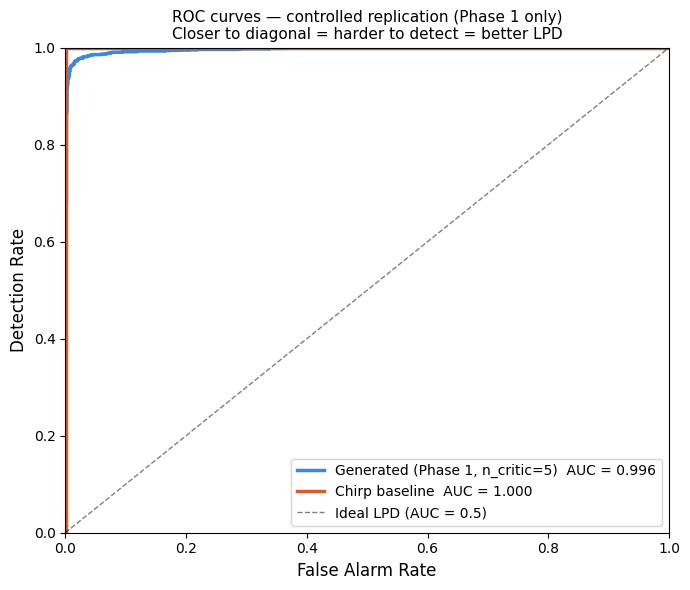

In [13]:
detector.eval()

def get_scores(signals: torch.Tensor, n: int = N_EVAL) -> np.ndarray:
    scores = []
    with torch.no_grad():
        for i in range(0, min(n, signals.size(0)), 128):
            batch = signals[i:i+128].to(DEVICE)
            scores.append(detector(batch).sigmoid().cpu())
    return torch.cat(scores).numpy().ravel()

gen_scores   = get_scores(generated)
chirp_scores = get_scores(chirps)
bg_scores    = get_scores(bg_pool[:N_EVAL])

print(f"Mean detector scores:")
print(f"  Generated  : {gen_scores.mean():.4f}  (1.0 = detected)")
print(f"  Chirp      : {chirp_scores.mean():.4f}")
print(f"  Background : {bg_scores.mean():.4f}  (0.0 = not detected)")

def compute_roc(signal_scores, bg_scores):
    y_true  = np.concatenate([np.ones(len(signal_scores)), np.zeros(len(bg_scores))])
    y_score = np.concatenate([signal_scores, bg_scores])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, auc(fpr, tpr)

fpr_gen,   tpr_gen,   auc_gen   = compute_roc(gen_scores,   bg_scores)
fpr_chirp, tpr_chirp, auc_chirp = compute_roc(chirp_scores, bg_scores)

print(f"\nAUC — Generated : {auc_gen:.4f}   (old collapsed run: 1.0000)")
print(f"AUC — Chirp     : {auc_chirp:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_gen, tpr_gen, color="#378ADD", linewidth=2.5,
        label=f"Generated (Phase 1, n_critic=5)  AUC = {auc_gen:.3f}")
ax.plot(fpr_chirp, tpr_chirp, color="#D85A30", linewidth=2.5,
        label=f"Chirp baseline  AUC = {auc_chirp:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Ideal LPD (AUC = 0.5)")
ax.set_xlabel("False Alarm Rate", fontsize=12)
ax.set_ylabel("Detection Rate", fontsize=12)
ax.set_title("ROC curves — controlled replication (Phase 1 only)\n"
             "Closer to diagonal = harder to detect = better LPD", fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eval061_02_roc_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 9.5 — Diagnostic: what is the detector actually keying on?

AUC is 0.9958 despite healthy diversity. So the generated distribution is
individually diverse but still systematically separable from background.
This diagnostic looks for *where* that separation lives, using data already
in memory. Four probes:

1. **Power Spectral Density (PSD)** — is generated energy distributed across
   frequency the same way as background? A shape mismatch here is the most
   common and most fixable cause.
2. **Per-sample amplitude histogram** — do the I/Q value distributions match?
   The generator's `2·tanh(x/2)` output could impose a subtle envelope that
   unit-std normalisation doesn't erase.
3. **Per-sample statistics** (kurtosis, peak-to-average power) — cheap scalar
   fingerprints a detector can latch onto.
4. **Detector score vs SNR** — is detectability uniform, or driven by a
   specific SNR regime of the conditioning background?

None of this trains anything — it's all measurement on existing tensors.

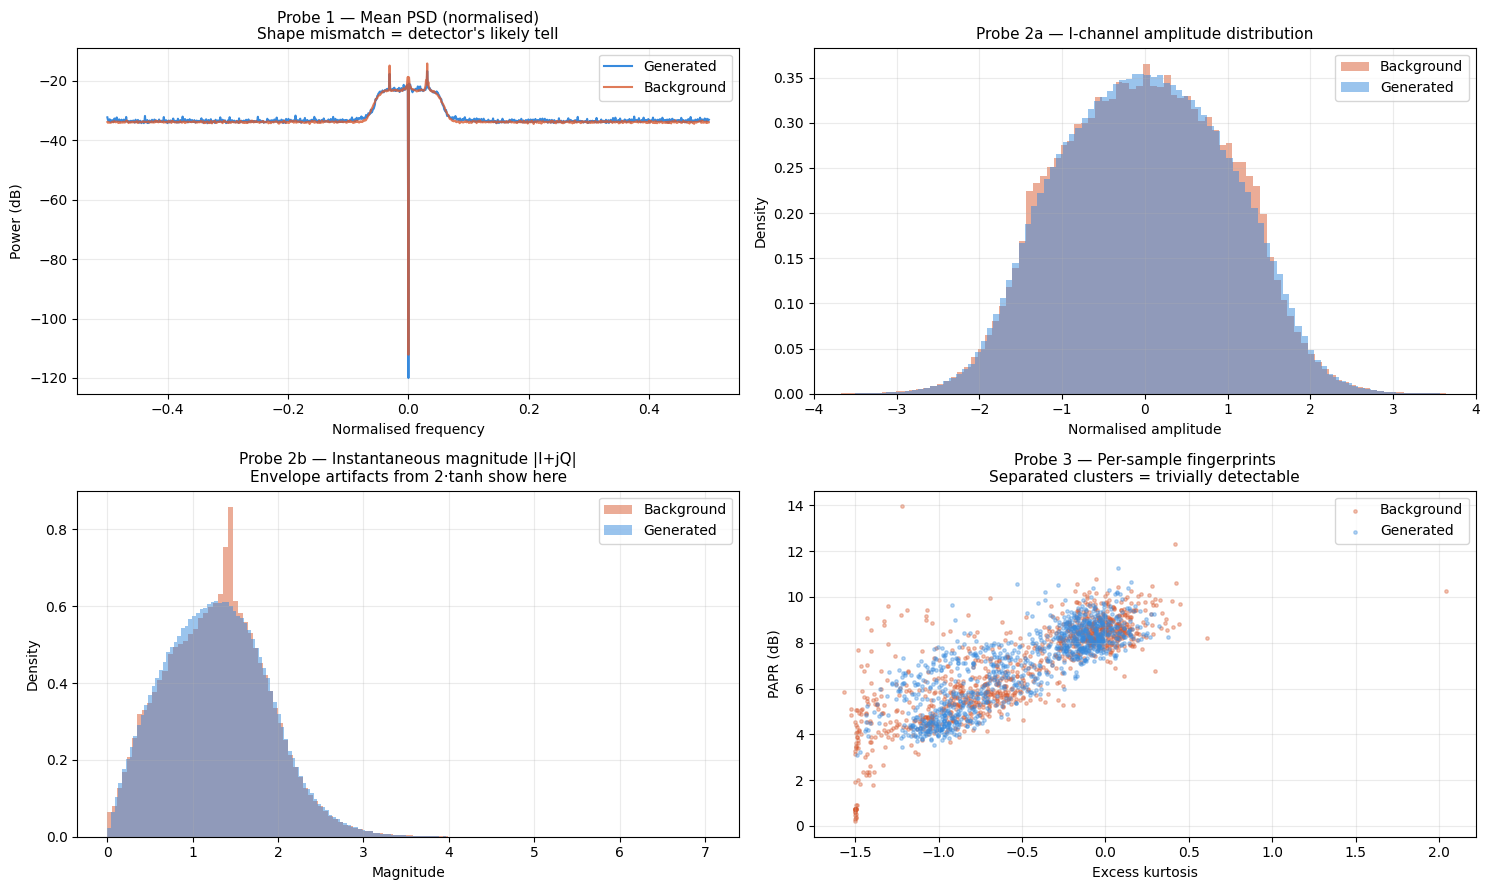

Distribution comparison (generated vs background):
  I-channel kurtosis : gen -0.501 ± 0.436   bg -0.513 ± 0.526
  PAPR (dB)          : gen 7.004 ± 1.680   bg 6.906 ± 2.025
  Magnitude mean     : gen 1.2792   bg 1.2830
  Magnitude max      : gen 5.1815    bg 7.0463

  PSD symmetric-KL   : 0.0345 bits  (0 = identical spectra; >0.1 = detector can likely use spectrum alone)


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ── prep: matched-size samples, complex form ─────────────────────────────────
n_probe = 1024
g = generated[:n_probe]                    # (n, 2, 1024)
b = bg_pool[:n_probe]                       # (n, 2, 1024)

g_complex = (g[:, 0, :] + 1j * g[:, 1, :]).numpy()   # (n, 1024)
b_complex = (b[:, 0, :] + 1j * b[:, 1, :]).numpy()

# ── PROBE 1: Power Spectral Density ──────────────────────────────────────────
# Average |FFT|^2 across samples. Same normalisation for both, so any
# shape difference is real, not an artifact of scaling.
def mean_psd(x_complex):
    spec = np.fft.fftshift(np.fft.fft(x_complex, axis=1), axes=1)
    psd  = (np.abs(spec) ** 2).mean(axis=0)
    return psd / psd.sum()                 # normalise to a distribution

psd_g = mean_psd(g_complex)
psd_b = mean_psd(b_complex)
freqs = np.fft.fftshift(np.fft.fftfreq(1024))

# ── PROBE 2: amplitude histograms (I channel and instantaneous magnitude) ────
gi = g[:, 0, :].numpy().ravel()
bi = b[:, 0, :].numpy().ravel()
gmag = np.abs(g_complex).ravel()
bmag = np.abs(b_complex).ravel()

# ── PROBE 3: per-sample scalar fingerprints ──────────────────────────────────
def kurtosis(x):                            # excess kurtosis per sample
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True) + 1e-8
    return (((x - m) / s) ** 4).mean(axis=1) - 3.0

def papr(x_complex):                        # peak-to-average power ratio (dB)
    p = np.abs(x_complex) ** 2
    return 10 * np.log10(p.max(axis=1) / (p.mean(axis=1) + 1e-12))

kurt_g = kurtosis(g[:, 0, :].numpy());  kurt_b = kurtosis(b[:, 0, :].numpy())
papr_g = papr(g_complex);               papr_b = papr(b_complex)

# ── plot probes 1–3 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0,0].plot(freqs, 10*np.log10(psd_g + 1e-12), color="#378ADD", lw=1.5, label="Generated")
axes[0,0].plot(freqs, 10*np.log10(psd_b + 1e-12), color="#D85A30", lw=1.5, label="Background", alpha=0.8)
axes[0,0].set_title("Probe 1 — Mean PSD (normalised)\nShape mismatch = detector's likely tell", fontsize=11)
axes[0,0].set_xlabel("Normalised frequency"); axes[0,0].set_ylabel("Power (dB)")
axes[0,0].legend(); axes[0,0].grid(alpha=0.25)

axes[0,1].hist(bi, bins=120, density=True, alpha=0.5, color="#D85A30", label="Background")
axes[0,1].hist(gi, bins=120, density=True, alpha=0.5, color="#378ADD", label="Generated")
axes[0,1].set_title("Probe 2a — I-channel amplitude distribution", fontsize=11)
axes[0,1].set_xlabel("Normalised amplitude"); axes[0,1].set_ylabel("Density")
axes[0,1].legend(); axes[0,1].set_xlim(-4, 4); axes[0,1].grid(alpha=0.25)

axes[1,0].hist(bmag, bins=120, density=True, alpha=0.5, color="#D85A30", label="Background")
axes[1,0].hist(gmag, bins=120, density=True, alpha=0.5, color="#378ADD", label="Generated")
axes[1,0].set_title("Probe 2b — Instantaneous magnitude |I+jQ|\nEnvelope artifacts from 2·tanh show here", fontsize=11)
axes[1,0].set_xlabel("Magnitude"); axes[1,0].set_ylabel("Density")
axes[1,0].legend(); axes[1,0].grid(alpha=0.25)

axes[1,1].scatter(kurt_b, papr_b, s=6, alpha=0.35, color="#D85A30", label="Background")
axes[1,1].scatter(kurt_g, papr_g, s=6, alpha=0.35, color="#378ADD", label="Generated")
axes[1,1].set_title("Probe 3 — Per-sample fingerprints\nSeparated clusters = trivially detectable", fontsize=11)
axes[1,1].set_xlabel("Excess kurtosis"); axes[1,1].set_ylabel("PAPR (dB)")
axes[1,1].legend(); axes[1,1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eval061_04_detector_diagnostic.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── numeric summary ──────────────────────────────────────────────────────────
print("Distribution comparison (generated vs background):")
print(f"  I-channel kurtosis : gen {kurt_g.mean():+.3f} ± {kurt_g.std():.3f}   "
      f"bg {kurt_b.mean():+.3f} ± {kurt_b.std():.3f}")
print(f"  PAPR (dB)          : gen {papr_g.mean():.3f} ± {papr_g.std():.3f}   "
      f"bg {papr_b.mean():.3f} ± {papr_b.std():.3f}")
print(f"  Magnitude mean     : gen {gmag.mean():.4f}   bg {bmag.mean():.4f}")
print(f"  Magnitude max      : gen {gmag.max():.4f}    bg {bmag.max():.4f}")

# spectral divergence: how different are the two PSDs? (symmetric KL, in bits)
def sym_kl(p, q):
    p = p + 1e-12; q = q + 1e-12
    return 0.5 * (np.sum(p*np.log2(p/q)) + np.sum(q*np.log2(q/p)))
print(f"\n  PSD symmetric-KL   : {sym_kl(psd_g, psd_b):.4f} bits  "
      f"(0 = identical spectra; >0.1 = detector can likely use spectrum alone)")

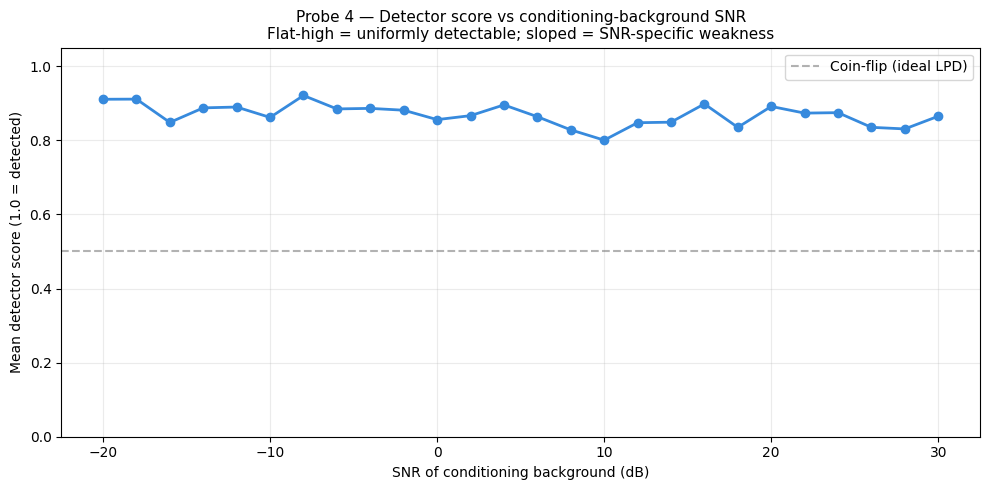

Mean detector score by SNR regime:
  -20 dB : 0.911   (n=159)
  -18 dB : 0.911   (n=147)
  -16 dB : 0.848   (n=141)
  -14 dB : 0.888   (n=166)
  -12 dB : 0.890   (n=165)
  -10 dB : 0.862   (n=148)
   -8 dB : 0.921   (n=139)
   -6 dB : 0.885   (n=161)
   -4 dB : 0.886   (n=166)
   -2 dB : 0.881   (n=142)
   +0 dB : 0.856   (n=138)
   +2 dB : 0.867   (n=182)
   +4 dB : 0.896   (n=155)
   +6 dB : 0.864   (n=137)
   +8 dB : 0.828   (n=169)
  +10 dB : 0.800   (n=141)
  +12 dB : 0.848   (n=163)
  +14 dB : 0.849   (n=137)
  +16 dB : 0.898   (n=170)
  +18 dB : 0.835   (n=147)
  +20 dB : 0.892   (n=177)
  +22 dB : 0.874   (n=154)
  +24 dB : 0.875   (n=182)
  +26 dB : 0.835   (n=181)
  +28 dB : 0.831   (n=155)
  +30 dB : 0.865   (n=174)


In [18]:
# ── PROBE 4: is detectability driven by a specific SNR regime? ────────────────
# The generated waveforms were conditioned on background samples spanning all
# SNRs. If the detector only nails the low- or high-SNR ones, that localises
# the problem. We re-fetch conditioning samples WITH their SNR labels.

detector.eval()
snr_scores = {snr: [] for snr in SNR_VALUES}

with torch.no_grad():
    collected = 0
    for x_batch, _, z_batch in loader_gen:
        z = torch.randn(x_batch.size(0), 512, 1, device=DEVICE)
        x_gen = G(z, x_batch.to(DEVICE))
        # normalise same as everywhere else
        m = x_gen.mean(dim=2, keepdim=True); s = x_gen.std(dim=2, keepdim=True) + 1e-8
        x_gen = (x_gen - m) / s
        scores = detector(x_gen).sigmoid().cpu().numpy().ravel()

        for score, snr in zip(scores, z_batch.numpy().ravel()):
            snr_scores[int(snr)].append(score)
        collected += x_batch.size(0)
        if collected >= 4096:
            break

snrs_sorted = sorted(s for s in SNR_VALUES if len(snr_scores[s]) > 0)
mean_by_snr = [np.mean(snr_scores[s]) for s in snrs_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snrs_sorted, mean_by_snr, "o-", color="#378ADD", lw=2, markersize=6)
ax.axhline(0.5, color="gray", ls="--", alpha=0.6, label="Coin-flip (ideal LPD)")
ax.set_title("Probe 4 — Detector score vs conditioning-background SNR\n"
             "Flat-high = uniformly detectable; sloped = SNR-specific weakness", fontsize=11)
ax.set_xlabel("SNR of conditioning background (dB)")
ax.set_ylabel("Mean detector score (1.0 = detected)")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eval061_05_score_vs_snr.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Mean detector score by SNR regime:")
for s in snrs_sorted:
    if len(snr_scores[s]) > 0:
        print(f"  {s:+3d} dB : {np.mean(snr_scores[s]):.3f}   (n={len(snr_scores[s])})")

## 10. Sensing metrics — for completeness

**Important context:** this generator was trained with Phase 1 only — no
ambiguity loss. Nothing in its training objective rewards a good ambiguity
function. We compute these metrics anyway so we have a "before" baseline
to compare against once Phase 2 fine-tuning is applied on top of this
checkpoint — that comparison (Phase 1 alone vs Phase 1 + ambiguity loss)
will show exactly how much the ambiguity loss contributes.

Do not expect these numbers to look like the old run's Phase 2 sensing
results (MW=1, IDA=0.678) — that run had the ambiguity loss actively
shaping its output. This run had no such pressure.

In [14]:
def compute_sensing_metrics(signals: torch.Tensor, n_sample: int = 128) -> dict:
    """Compute MW, PSL, IDA on the zero-Doppler slice of the ambiguity function."""
    idx  = torch.randperm(signals.size(0))[:n_sample]
    sigs = signals[idx, :, :256].to(DEVICE)
    N    = 256

    mw_list, psl_list, ida_list = [], [], []

    with torch.no_grad():
        for i in range(0, n_sample, 8):
            batch = sigs[i:i+8]
            B     = batch.size(0)
            s_c   = torch.complex(batch[:, 0, :], batch[:, 1, :])

            zd = torch.zeros(B, N, device=DEVICE)
            for k in range(N):
                lag = s_c * torch.roll(s_c.conj(), shifts=k, dims=1)
                zd[:, k] = torch.abs(lag.sum(dim=1))

            zd_n = zd / (zd[:, 0:1] + 1e-8)

            for b in range(B):
                zd_b = zd_n[b].cpu().numpy()

                above = np.where(zd_b >= 0.5)[0]
                mw    = int(above[-1] - above[0]) if len(above) > 1 else 1
                mw_list.append(mw)

                side_start = (above[-1] + 1) if len(above) > 1 else 2
                sidelobes  = zd_b[side_start:]
                psl        = float(sidelobes.max()) if len(sidelobes) > 0 else 0.0
                psl_list.append(psl)

                ida = float(np.sum(zd_b[1:] ** 2))
                ida_list.append(ida)

    return {"mw": mw_list, "psl": psl_list, "ida": ida_list}


print("Computing sensing metrics...")
metrics_gen   = compute_sensing_metrics(generated)
print("  Generated ✓")
metrics_chirp = compute_sensing_metrics(chirps)
print("  Chirp ✓")

def summarise(m, name):
    print(f"\n{name}:")
    for k, v in m.items():
        arr = np.array(v)
        print(f"  {k.upper():<5} mean={arr.mean():.3f}  "
              f"std={arr.std():.3f}  median={np.median(arr):.3f}")

summarise(metrics_gen,   "Generated (Phase 1 only, n_critic=5)")
summarise(metrics_chirp, "Chirp baseline")

Computing sensing metrics...
  Generated ✓
  Chirp ✓

Generated (Phase 1 only, n_critic=5):
  MW    mean=137.922  std=126.612  median=255.000
  PSL   mean=0.080  std=0.098  median=0.000
  IDA   mean=12.763  std=23.606  median=10.787

Chirp baseline:
  MW    mean=255.000  std=0.000  median=255.000
  PSL   mean=0.000  std=0.000  median=0.000
  IDA   mean=184.952  std=0.000  median=184.952


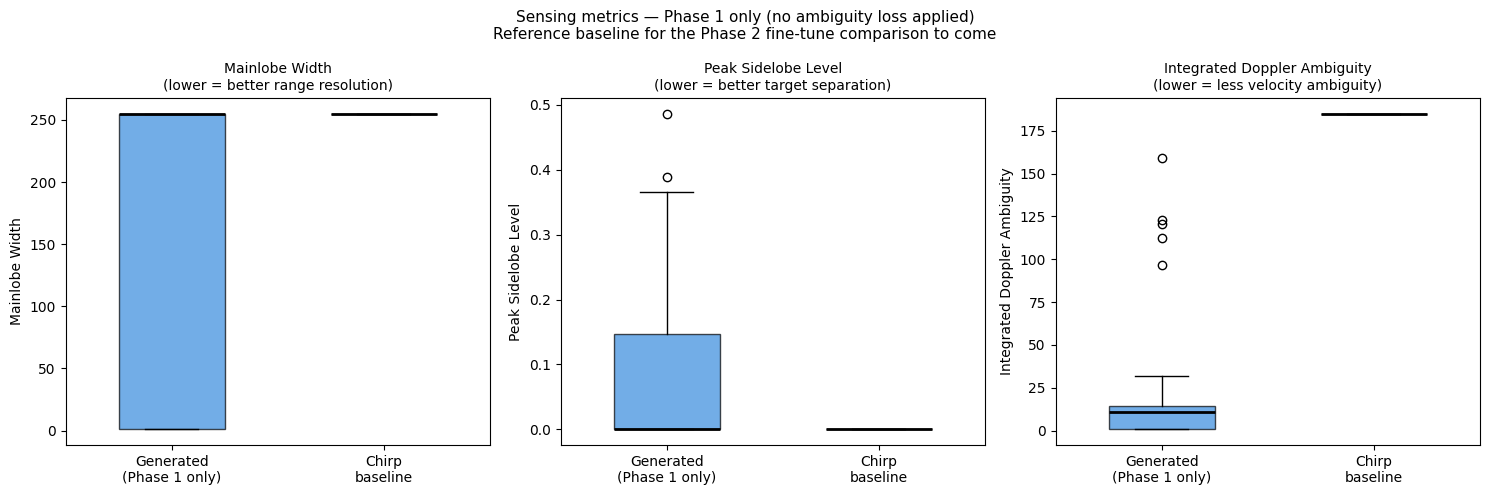

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metric_keys   = ["mw", "psl", "ida"]
metric_labels = [
    "Mainlobe Width\n(lower = better range resolution)",
    "Peak Sidelobe Level\n(lower = better target separation)",
    "Integrated Doppler Ambiguity\n(lower = less velocity ambiguity)",
]
labels  = ["Generated\n(Phase 1 only)", "Chirp\nbaseline"]
colors  = ["#378ADD", "#D85A30"]
metrics = [metrics_gen, metrics_chirp]

for ax, key, ylabel in zip(axes, metric_keys, metric_labels):
    data = [np.array(m[key]) for m in metrics]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                      medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel.split("\n")[0], fontsize=10)
    ax.set_title(ylabel, fontsize=10)

fig.suptitle(
    "Sensing metrics — Phase 1 only (no ambiguity loss applied)\n"
    "Reference baseline for the Phase 2 fine-tune comparison to come",
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eval061_03_sensing_metrics.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 11. Summary

In [16]:
FAR_TARGET = 0.1

def dr_at_far(fpr, tpr, far):
    idx = np.searchsorted(fpr, far)
    return float(tpr[min(idx, len(tpr) - 1)])

dr_gen   = dr_at_far(fpr_gen,   tpr_gen,   FAR_TARGET)
dr_chirp = dr_at_far(fpr_chirp, tpr_chirp, FAR_TARGET)

print("=" * 68)
print("CONTROLLED REPLICATION — EVALUATION SUMMARY (Phase 1 only, n_critic=5)")
print("=" * 68)
print(f"Checkpoint: epoch {ckpt['epoch']}, W-dist {ckpt['metrics']['w_dist']:.4f}")
print("-" * 68)
print(f"{'Metric':<32} {'Generated':>16} {'Chirp':>14}")
print("-" * 68)
print(f"{'AUC (lower = harder to detect)':<32} {auc_gen:>16.4f} {auc_chirp:>14.4f}")
print(f"{'Detection rate @ 10% FAR':<32} {dr_gen:>15.1%} {dr_chirp:>13.1%}")
print(f"{'Mainlobe width (median)':<32} {np.median(metrics_gen['mw']):>16.1f} "
      f"{np.median(metrics_chirp['mw']):>14.1f}")
print(f"{'PSL (median)':<32} {np.median(metrics_gen['psl']):>16.3f} "
      f"{np.median(metrics_chirp['psl']):>14.3f}")
print(f"{'IDA (median)':<32} {np.median(metrics_gen['ida']):>16.3f} "
      f"{np.median(metrics_chirp['ida']):>14.3f}")
print("-" * 68)
print(f"{'Diversity: std_ratio':<32} {div['std_ratio']:>16.4f}")
print(f"{'Diversity: cos_gap':<32} {div['cos_gap']:>+16.4f}")
print("=" * 68)

print(f"""
Interpretation:
  AUC {auc_gen:.4f} vs the OLD collapsed run's AUC = 1.0000.
  {'This is a substantial improvement — n_critic=5 appears to have '
   'meaningfully reduced detectability.' if auc_gen < 0.95 else
   'Still highly detectable — n_critic alone may not be sufficient; '
   'the ambiguity loss and/or other factors likely also play a role.'}

  Diversity metrics (cos_gap={div['cos_gap']:+.4f}, std_ratio={div['std_ratio']:.4f})
  remained stable throughout training and match the live training monitor's
  readings — consistent with a generator that did not mode-collapse.

  Sensing metrics are reported as a Phase-1-only baseline. They are not
  expected to be strong, since no ambiguity loss was applied. The
  meaningful comparison will be this baseline vs the same checkpoint
  after Phase 2 fine-tuning.

Next step: Phase 2 fine-tune (ambiguity loss) on top of this checkpoint,
then re-run evaluation for the full before/after comparison against the
old collapsed run.
""")

CONTROLLED REPLICATION — EVALUATION SUMMARY (Phase 1 only, n_critic=5)
Checkpoint: epoch 70, W-dist 4.6480
--------------------------------------------------------------------
Metric                                  Generated          Chirp
--------------------------------------------------------------------
AUC (lower = harder to detect)             0.9958         0.9995
Detection rate @ 10% FAR                   99.2%        100.0%
Mainlobe width (median)                     255.0          255.0
PSL (median)                                0.000          0.000
IDA (median)                               10.787        184.952
--------------------------------------------------------------------
Diversity: std_ratio                       1.0053
Diversity: cos_gap                        +0.0094

Interpretation:
  AUC 0.9958 vs the OLD collapsed run's AUC = 1.0000.
  Still highly detectable — n_critic alone may not be sufficient; the ambiguity loss and/or other factors likely also play a ro